In [1]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/machine-learning-comp-432-project/sample_submission.csv
/kaggle/input/machine-learning-comp-432-project/train.csv
/kaggle/input/machine-learning-comp-432-project/test.csv


Train: (115406, 502)
Test : (49460, 501)

STARTING K-FOLD TRAINING

Fold 1 / 5 

Fold 1 | Epoch 1/20 | Loss: 2.8472
Fold 1 | Epoch 2/20 | Loss: 2.0507
Fold 1 | Epoch 3/20 | Loss: 1.6279
Fold 1 | Epoch 4/20 | Loss: 1.3079
Fold 1 | Epoch 5/20 | Loss: 1.0648
Fold 1 | Epoch 6/20 | Loss: 0.8620
Fold 1 | Epoch 7/20 | Loss: 0.7168
Fold 1 | Epoch 8/20 | Loss: 0.5949
Fold 1 | Epoch 9/20 | Loss: 0.5105
Fold 1 | Epoch 10/20 | Loss: 0.4428
Fold 1 | Epoch 11/20 | Loss: 0.3880
Fold 1 | Epoch 12/20 | Loss: 0.3446
Fold 1 | Epoch 13/20 | Loss: 0.3192
Fold 1 | Epoch 14/20 | Loss: 0.2830
Fold 1 | Epoch 15/20 | Loss: 0.2670
Fold 1 | Epoch 16/20 | Loss: 0.2483
Fold 1 | Epoch 17/20 | Loss: 0.2330
Fold 1 | Epoch 18/20 | Loss: 0.2274
Fold 1 | Epoch 19/20 | Loss: 0.2176
Fold 1 | Epoch 20/20 | Loss: 0.2083
Fold 1 Validation Accuracy: 0.6077

Fold 2 / 5 

Fold 2 | Epoch 1/20 | Loss: 2.8499
Fold 2 | Epoch 2/20 | Loss: 2.0427
Fold 2 | Epoch 3/20 | Loss: 1.6204
Fold 2 | Epoch 4/20 | Loss: 1.3047
Fold 2 | Epoch 5/20

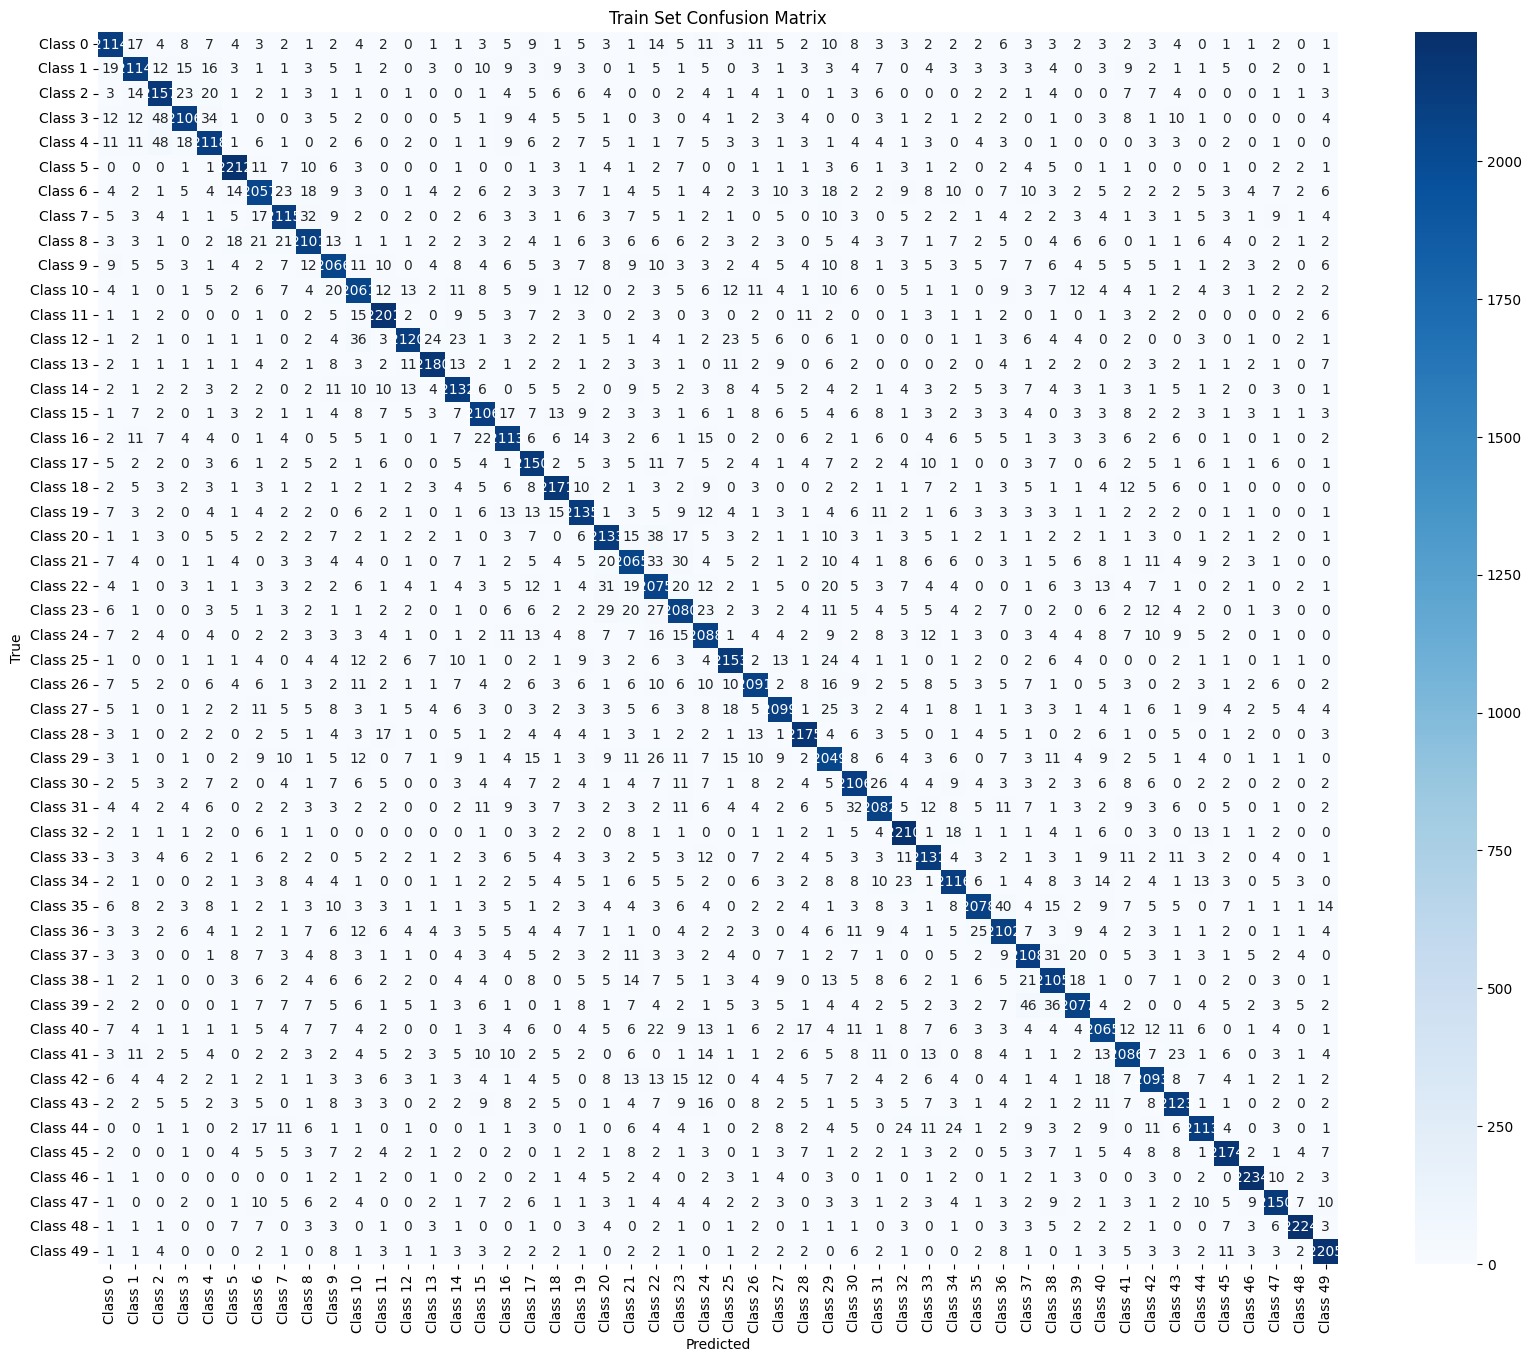


Validation Set Accuracy (Best Model): 0.6116

Validation Set Classification Report:
              precision    recall  f1-score   support

     Class 0       0.61      0.60      0.60       465
     Class 1       0.58      0.55      0.57       422
     Class 2       0.63      0.68      0.65       450
     Class 3       0.65      0.56      0.60       433
     Class 4       0.64      0.63      0.63       487
     Class 5       0.75      0.80      0.77       467
     Class 6       0.50      0.46      0.48       458
     Class 7       0.58      0.57      0.57       426
     Class 8       0.58      0.57      0.58       446
     Class 9       0.47      0.48      0.48       444
    Class 10       0.48      0.49      0.48       452
    Class 11       0.72      0.77      0.74       446
    Class 12       0.75      0.63      0.68       479
    Class 13       0.82      0.75      0.78       498
    Class 14       0.61      0.64      0.63       462
    Class 15       0.60      0.59      0.59       

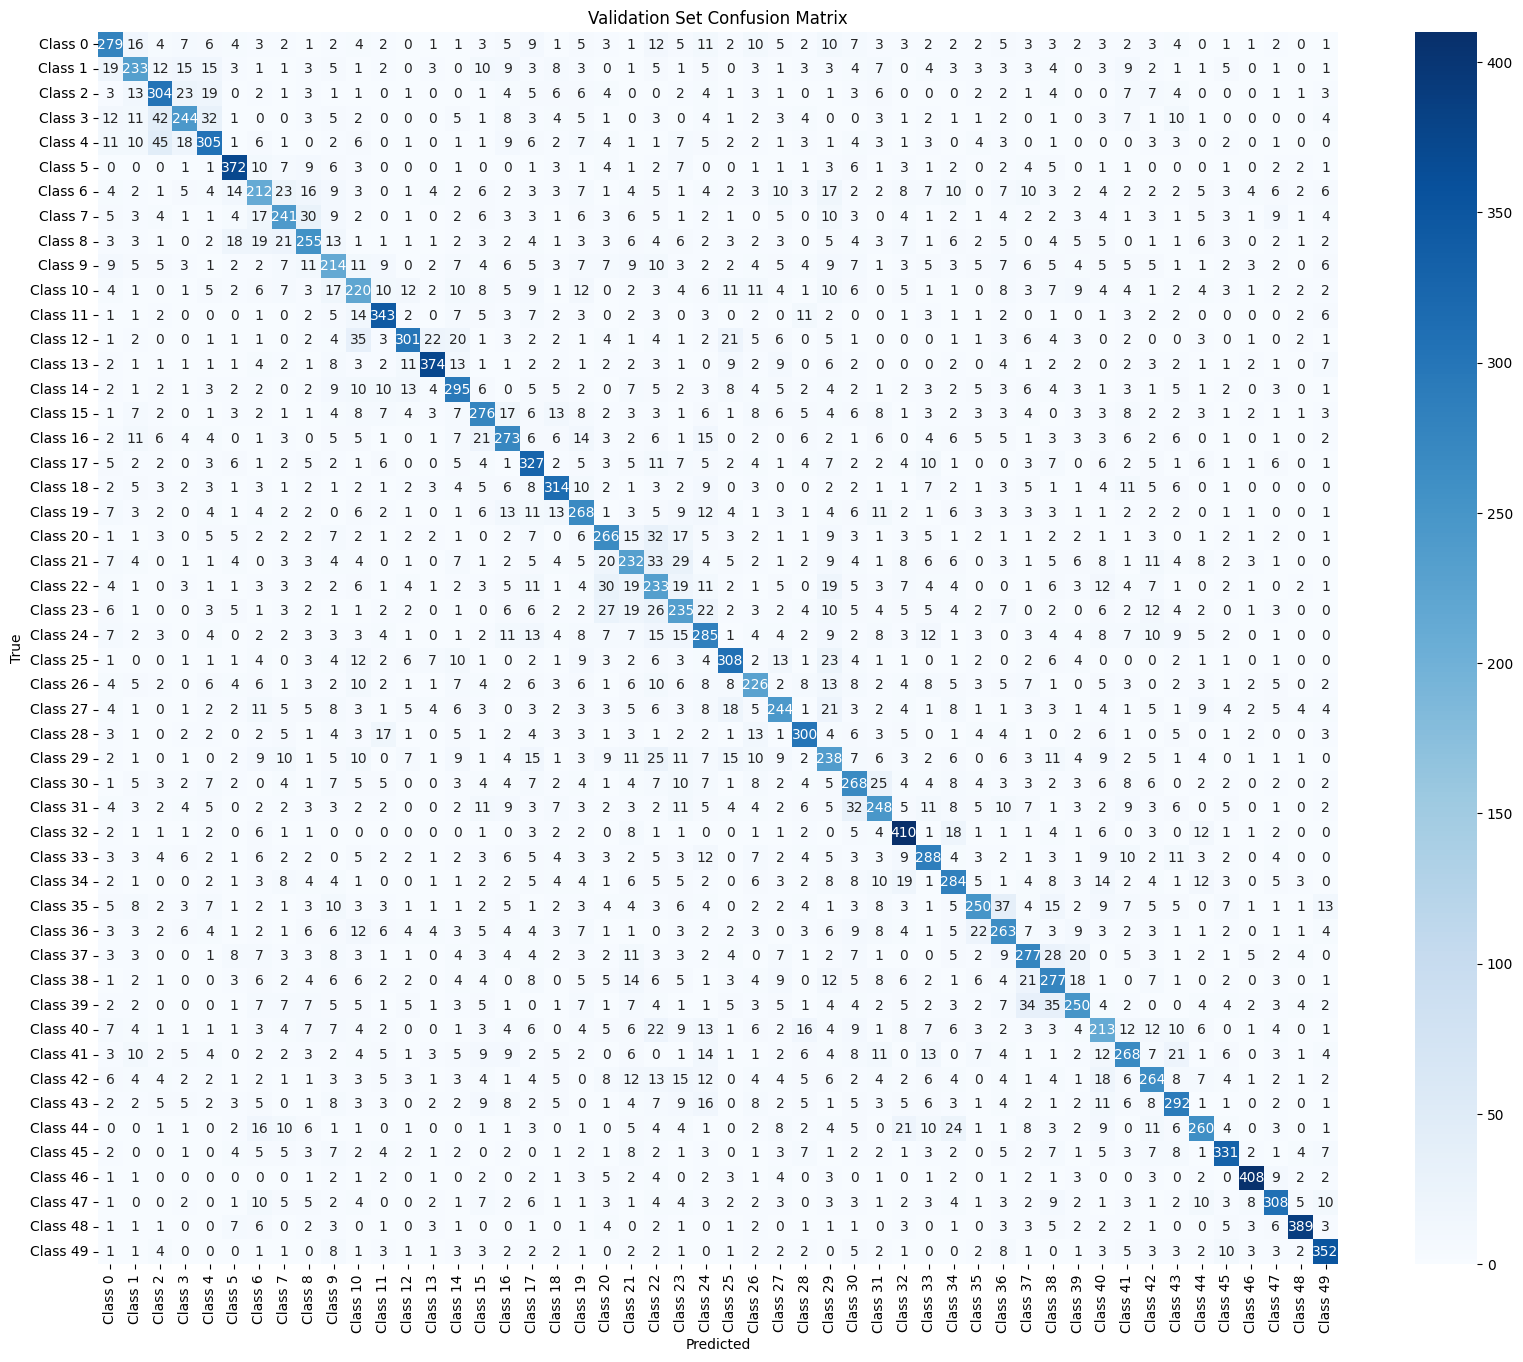

Submission file saved to: /kaggle/working/submission.csv


,id,label
0,0,0
1,1,44
2,2,40
3,3,15
4,4,0


In [2]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Load Data
# ============================================================

train_path = "/kaggle/input/machine-learning-comp-432-project/train.csv"
test_path  = "/kaggle/input/machine-learning-comp-432-project/test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# Features
feature_cols = [c for c in train_df.columns if c.startswith("feature")]

X = train_df[feature_cols].values
y = train_df["label"].values
X_test = test_df[feature_cols].values

NUM_FEATURES = X.shape[1]
NUM_CLASSES = 50 # no of unique labels

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

# ============================================================
# Dataset Class
# ============================================================

class FeatureDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]


full_dataset = FeatureDataset(X, y)

# ============================================================
# MLP MODEL
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.layers(x)


# ============================================================
# K-FOLD TRAINING
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 20
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_accuracies = []
best_model_state = None
best_fold_acc = 0
best_val_indices = None #to save the indexes of the the validation set of the best fold

print("\nSTARTING K-FOLD TRAINING")

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\nFold {fold+1} / {k_folds} \n")

    train_subset = Subset(full_dataset, train_idx)
    val_subset   = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=256, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=256, shuffle=False)

    # Reinitialize model each fold
    model = MLP(NUM_FEATURES, NUM_CLASSES).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    # TRAIN
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Fold {fold+1} | Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

    # VALIDATION (ONCE PER FOLD)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            preds = outputs.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    fold_acc = correct / total
    fold_accuracies.append(fold_acc)

    print(f"Fold {fold+1} Validation Accuracy: {fold_acc:.4f}")

    # Track best model
    if fold_acc > best_fold_acc:
        best_fold_acc = fold_acc
        best_model_state = model.state_dict()
        best_val_indices = val_idx  # save index of the validation set of the best fold

print("\nK-FOLD ACCURACIES:", fold_accuracies)
print(" BEST FOLD ACCURACY:", best_fold_acc)

# Save the best model
torch.save(best_model_state, "best_model.pth")

# ============================================================
# FINAL TEST PREDICTION
# ============================================================

# Reload best model
model = MLP(NUM_FEATURES, NUM_CLASSES).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

########### assess on the whole train set
train_loader_full = DataLoader(full_dataset, batch_size=256, shuffle=False)
y_true_train = []
y_pred_train = []

with torch.no_grad():
    for xb, yb in train_loader_full:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(1)
        y_true_train.extend(yb.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

train_accuracy = accuracy_score(y_true_train, y_pred_train)
print(f"\nTrain Set Accuracy (Best Model): {train_accuracy:.4f}")
print("\nTrain Set Classification Report:")
print(classification_report(y_true_train, y_pred_train, target_names=[f"Class {i}" for i in range(NUM_CLASSES)]))
# confusion matrix for the train set
cm_train = confusion_matrix(y_true_train, y_pred_train)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Class {i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"Class {i}" for i in range(NUM_CLASSES)])
plt.title('Train Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
plt.savefig('/kaggle/working/train_confusion_matrix.png')
plt.close()



###########  assess on the validation set of the best model
best_val_subset = Subset(full_dataset, best_val_indices)
best_val_loader = DataLoader(best_val_subset, batch_size=256, shuffle=False)
y_true_val = []
y_pred_val = []

with torch.no_grad():
    for xb, yb in best_val_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(1)
        y_true_val.extend(yb.cpu().numpy())
        y_pred_val.extend(preds.cpu().numpy())

val_accuracy = accuracy_score(y_true_val, y_pred_val)
print(f"\nValidation Set Accuracy (Best Model): {val_accuracy:.4f}")
print("\nValidation Set Classification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=[f"Class {i}" for i in range(NUM_CLASSES)]))
# confusion matrix for the validation set
cm_val = confusion_matrix(y_true_val, y_pred_val)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Class {i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"Class {i}" for i in range(NUM_CLASSES)])
plt.title('Validation Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
plt.savefig('/kaggle/working/val_confusion_matrix.png')
plt.close()



# Load test features
test_df = pd.read_csv(test_path)
test_ids = test_df["id"]

# Scale features
X_test = test_df.drop(columns=["id"]).values
X_test = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Predict
with torch.no_grad():
    outputs = model(X_test_tensor)
    preds = outputs.argmax(1).cpu().numpy()

# Create submission file
submission = pd.DataFrame({
    "id": test_ids,
    "label": preds
})

submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

print("Submission file saved to:", submission_path)
submission.head()


